## 1. K均值

### 1.1 K均值算法

In [65]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs # make_blobs 是一个用来生成各向同性高斯斑点（blobs）的函数，常用于测试聚类算法
# 生成模型， 这里 cluster_std是为了描述样本的离散程度
X, y = make_blobs(n_samples=300, n_features=2, centers=5,
                    cluster_std=0.60, random_state=0)
# KMeans只关心“距离”。它通过计算每个点到中心的欧氏距离来分配类别。
k=5
kMeans = KMeans(n_clusters=k, random_state=42)
y_pred = kMeans.fit_predict(X)
print(y_pred[:10])
print(y_pred is kMeans.labels_)  # 判断预测是否与真实标签一致
print(kMeans.cluster_centers_)   # 打印中心点

[1 2 3 1 0 0 4 3 4 2]
True
[[-1.66877007  2.91652498]
 [ 9.12239104 -2.42822185]
 [-1.24268927  7.75317247]
 [ 0.96475862  4.4261437 ]
 [ 2.00401597  0.84371973]]


d:\Anaconda\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [66]:
# 我们来测试一下新数据
import numpy as np
X_new = np.array([[0,2],[3,2],[-3,3],[-3,2.5]])
print(kMeans.predict(X_new))

''' 硬聚类：将每个实例分配给一个单独的集群;
软聚类：为每个实例分配每个集群一个分数（与各质心之间的距离或相似性分数）'''
''' 我们可以使用transform()方法获取测量每个实例到每个质心之间的距离
从而更直观地观察数据分布并借此判断模型预测是否正确'''
print(kMeans.transform(X_new).round(2))

[0 4 0 0]
[[ 1.9  10.14  5.89  2.61  2.31]
 [ 4.76  7.56  7.15  3.17  1.53]
 [ 1.33 13.28  5.07  4.21  5.45]
 [ 1.39 13.09  5.54  4.41  5.27]]


### 1.2 K均值算法的局限性
1. 需要多次运行才能避免次优解，还需要指定集群数
2. 当处理椭圆集群时，应该考虑特征缩放，防止集群变形从而减差k均值性能
3. 特别地，高斯混合模型在处理椭圆集群上非常有效

### 1.3 质心初始化的优化

#### 1.3.1 质心初始化方法

In [67]:
# 1. 当我之前运行过另一种聚类算法得到了质心的位置
good_init = np.array([[-3,3],[-3,2],[-3,1],[-1,2],[0,2]])
kMeans = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
kMeans.fit(X)
'''这里n_init被设为了 1 是因为当我们通过 init=good_init 手动指定了质心位置时，初始状态已经是确定的了。
如果你设置 n_init=10，算法由于每次都使用你指定的同一组质心，跑 10 次的结果也会完全一样，这会白白浪费 9 次的计算资源。'''

# 2. 使用不同的随机初始化多次运行算法并保留最优解
# 也就是指定上面的n_init,这里我们可以访问模型的惯性
print(kMeans.inertia_)

211.21561192615172


d:\Anaconda\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


### 1. 为什么先运行另一种算法？（“先导算法”逻辑）

这听起来像“为了跑 K-Means 先跑个别的算法”多此一举，但其实这是基于不同算法的特性互补：

* **计算开销的权衡：**
有些算法（如 **凝聚层次聚类 Agglomerative Clustering**）能产生非常精准的聚类结构，但它的复杂度很高，在处理几十万条数据时速度极慢。
    * **策略：** 我们可以先对原始数据进行**抽样**，在小样本上跑一个昂贵但精准的算法得到质心，然后将这些质心作为“种子”，让 K-Means 在全量大数据集上进行快速迭代。


* **抗噪能力：**
K-Means 对离群点（Outliers）很敏感。我们可以先用 **DBSCAN** 这种能识别噪声的算法过滤掉干扰点，找到核心数据的中心，再交给 K-Means 细化边界。
    * **多阶段优化：**
在处理多模态数据或动态更新的数据流时，我们可能会用前一次计算的结果作为下一次计算的起点，这样算法能更快收敛。

### 2. `n_init` 是什么？

在 Scikit-learn 的 `KMeans` 中，`n_init` 是一个非常核心的超参数。

* **定义：** 它代表算法**重新初始化质心并运行完整算法的次数**。
* **为什么要运行多次？**
正如你上一张图中看到的，K-Means 很容易陷入局部最优（次优解）。为了增加找到“全局最优解”的概率，算法默认会随机选 10 组不同的初始质心，跑 10 次独立的聚类。
* **最后选哪个？**
在这 10 次运行结束后，算法会对比每一轮的 **惯性（Inertia）**（即点到质心的距离平方和），并只保留 Inertia 最小（即效果最好）的那次结果。

---

### 补充：3.K均值++算法
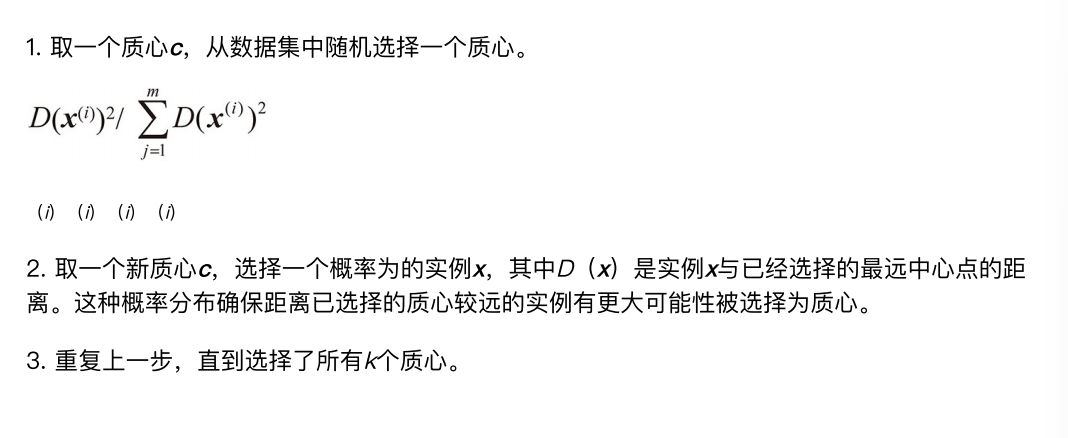
#### 1. 设定场景

* **数据集 $X$**：我们有 4 个点，位置分别是 $1, 2, 8, 10$。
* **目标**：我们要选出 3 个质心（$K=3$）。
* **当前进度**：
    * 第一个质心 $c_1$ 已经随机选好了，就在位置 **1**。
    * 第二个质心 $c_2$ 也选好了，就在位置 **8**。

* **任务**：我们要通过 $K$-Means++ 逻辑选出**第三个**质心。

#### 2. 计算每个点的 $D(x^{(i)})$

我们需要计算剩下的点到**已有质心阵营**（$1$ 和 $8$）的“盲区距离”。

| 样本点 $x^{(i)}$ | 到 $c_1(1)$ 的距离 | 到 $c_2(8)$ 的距离 | **$D(x^{(i)}) = \min$** (离谁近算谁) | **$D(x^{(i)})^2$** (平方项) |
| --- | --- | --- | --- | --- |
| **点 A (位置 1)** | 0 | 7 | $\min(0, 7) = \mathbf{0}$ | 0 |
| **点 B (位置 2)** | 1 | 6 | $\min(1, 6) = \mathbf{1}$ | 1 |
| **点 C (位置 8)** | 7 | 0 | $\min(7, 0) = \mathbf{0}$ | 0 |
| **点 D (位置 10)** | 9 | 2 | $\min(9, 2) = \mathbf{2}$ | 4 |

#### 3. 计算被选为“第三个质心”的概率

首先计算所有 $D^2$ 的总和（分母）：

$$\sum D^2 = 0 + 1 + 0 + 4 = 5$$

现在计算每个点中奖的概率 $P(x^{(i)})$：

* **点 A**：$0 / 5 = \mathbf{0\%}$（已经是质心了，不可能再选）
* **点 B**：$1 / 5 = \mathbf{20\%}$
* **点 C**：$0 / 5 = \mathbf{0\%}$（已经是质心了，不可能再选）
* **点 D**：$4 / 5 = \mathbf{80\%}$

#### 总结：
1. 只有 $\min$ 能确保：只要靠近任何一个已有的质心，就失去了竞争下一个质心的资格
2. 使用概率，而不直接看分母：防止离群值（该样本离所有已有质心都很远）带偏判断

#### 1.3.2 加速的K均值和小批量K均值
其中，在一些具有许多离群的大型数据集上，加速K均值主要通过避免许多不必要的距离计算优化

而小批量方法对于庞大数据集，则采取小型批次每次稍微移动质心位置

In [68]:
from sklearn.cluster import MiniBatchKMeans
minibatch_kMeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kMeans.fit(X)
# 相较常规的K均值算法，小批量均值的惯性一般略差，但是计算速度显著提高

d:\Anaconda\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 5120 or by setting the environment variable OMP_NUM_THREADS=2
  warnings.warn(


,n_clusters,5
,init,'k-means++'
,max_iter,100
,batch_size,1024
,verbose,0
,compute_labels,True
,random_state,42
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,'auto'


#### 1.3.3 寻找最佳离群数（设置K值）
> 一般而言，惯性并不是一个好的性能指标，当随着k的增加，惯性会不断降低

### 1. 选择惯性图像拐点（比较粗糙）
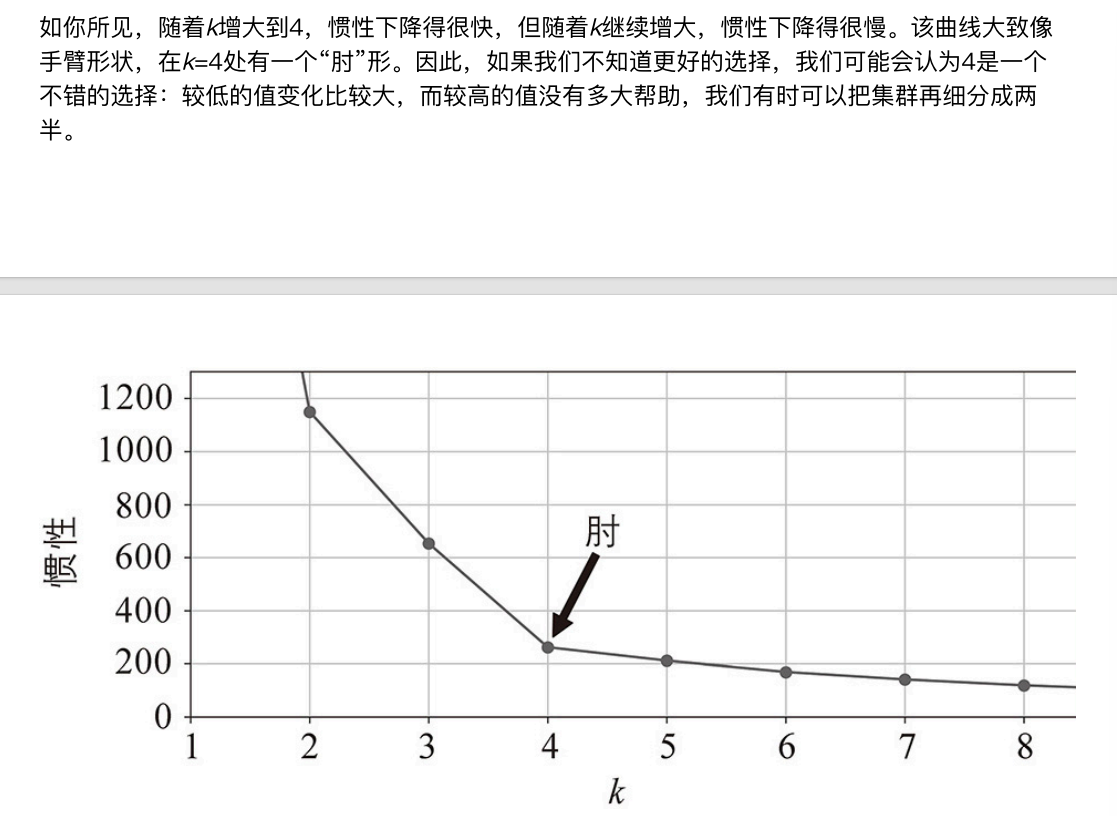

### 2. 轮廓分数（较精确但计算开销比较大）

**轮廓系数（Silhouette Coefficient）** 是用来量化评估“分类质量”的指标。它不像惯性（Inertia）只看距离，它更聪明，因为它同时考虑了“聚得紧不紧”和“分得开不开”。

公式如下：

$$s = \frac{b - a}{\max(a, b)}$$

我们可以把每一个样本点想象成一个学生，聚类就是分班。

* **$a$（凝聚度 - Intracluster distance）：**
这个样本点到**同班同学**的平均距离。
    * **希望 $a$ 越小越好：** $a$ 小说明你和自己班的人靠得近，班级内部很团结。

* **$b$（分离度 - Nearest-cluster distance）：**
这个样本点到**隔壁班**（最近的那个班）所有人的平均距离。
    * **希望 $b$ 越大越好：** $b$ 大说明你离别的班级很远，边界清晰。

#### **为什么结果在 -1 到 +1 之间？**

* **接近 +1：** 说明 $b \gg a$。你离同学很近，离外班很远。这是**近乎完美的分类**。
* **接近 0：** 说明 $b \approx a$。你站在两个班级的交界线上，分哪边都差不多。这是**聚类边界模糊**。
* **接近 -1：** 说明 $a > b$。你离外班的人比离自己班的人还近。这说明**你被分错班了**。

In [69]:
from sklearn.metrics import silhouette_score
print(silhouette_score(X,kMeans.labels_))
'''当运行完 kmeans.fit(X) 后，算法会给每一个数据点打上一个标签，存放在 .labels_ 属性里。
1. 它会针对数据集 X 中的每一个点，根据 labels_提供的分类信息，算出该点的轮廓系数 s。
2. 然后把所有点的 s 加起来取平均值。
3. 最终返回一个总分。'''

0.7222571625994793


'当运行完 kmeans.fit(X) 后，算法会给每一个数据点打上一个标签，存放在 .labels_ 属性里。\n1. 它会针对数据集 X 中的每一个点，根据 labels_提供的分类信息，算出该点的轮廓系数 s。\n2. 然后把所有点的 s 加起来取平均值。\n3. 最终返回一个总分。'

### 1.4 实际应用

#### 1.4.1 使用聚类进行图像分割

### 先补充一个图像数据方面的知识点

#### 1. 数据结构的“跨界”对齐

| 概念 | 通用数据集 $(m, n)$ | 图像数据集（展平后） | 物理意义 |
| --- | --- | --- | --- |
| **行索引 (Index)** | 第 $i$ 个样本 | 第 $i$ 个像素点 | **“谁”/“在哪”**。在图像里，它代表空间位置 $(h, w)$ 的扁平化结果。 |
| **列维度 (Features)** | 面积、卧室数、房龄 | **$C$ 通道 (R, G, B)** | **“是什么”/“长什么样”**。是描述这个点的特征维度。 |
| **具体数值 (Values)** | 80平米、3间、10年 | **像素值 (120, 255, 0)** | **特征的具体度量**。是算法真正用来计算距离的数据。 |

#### 2. 为什么说 $(H, W)$ 是“物理位置”？

在机器学习的视角下，如果你只做颜色聚类：

* **$H$ 和 $W$ 提供了“身份”**：它们告诉我们这个颜色属于照片的哪个部位。
* **但它们不参与“分类”**：K-Means 在计算 $D(x^{(i)})$ 时，只看 $C$ 维度的像素值。

这就像你统计全国房价：

* 房子的“经纬度”是它的**物理位置**（对应 $H, W$）。
* 房子的“面积、装修程度”是它的**特征**（对应 $C$）。
* 如果你只想根据“奢华程度”给房子分类，你可能只关心面积和装修，而不关心它在地图上的哪个坐标。**把图像 `reshape` 的过程，本质上就是把“地图”撕开，把所有的“房子”排成一排。**

#### 3. 一个有趣的延伸：如果把位置也当成特征？

既然你已经理解到这一步了，可以思考一个进阶问题：

如果你在 `reshape` 之后，给每个像素点不仅保留 `[R, G, B]`，还强行加上它的 `[H, W]` 坐标，变成一个 5 维的向量 `[R, G, B, H, W]` 再喂给 K-Means，会发生什么？

* **结果：** 聚类结果会同时考虑“颜色接近”和“位置接近”。
* **视觉效果：** 最终分出来的块状会更加连续，不会出现那种星星点点的杂色，因为算法现在觉得“离得远的颜色”即便一样，也不属于同一个类。这就是图像分割中更高级的算法（如 SLIC 超像素）的基础逻辑。

In [70]:
from PIL import Image
image = np.asarray(Image.open("image.png")) # 这里面填的是图片的具体路径
print(image.shape)

X = image.reshape(-1,3)
kMeans = KMeans(n_clusters=8, random_state=42).fit(X)
segmented_img = kMeans.cluster_centers_[kMeans.labels_]
''' 若kMeans.labels_的前十个标签为1，则segmented_img数组中前十个颜色等于kMeans.cluster_centers_[1]
即每个像素用所属集群中心值替代'''
segmented_img = segmented_img.reshape(image.shape)

(451, 677, 3)


#### 1.4.2 使用聚类进行半监督学习（只有少量已标记的实例）

我们把之前的“瓢虫图”和现在的“数字图（load_digits）”放在一起看：

### 1. 维度结构的本质区别

| 数据集 | 原始形状 | 聚类时的形状 | **样本 (m)** 是什么？ | **特征 (n)** 是什么？ |
| --- | --- | --- | --- | --- |
| **瓢虫图** | $(533, 800, 3)$ | **$(426400, 3)$** | **每一个像素点** | **R, G, B 三原色** |
| **数字图** | $(1797, 8, 8)$ | **$(1797, 64)$** | **每一张完整的数字图** | **64 个位置的灰度值** |

### 2. 深度拆解：为什么“样本”变了？

#### **在瓢虫图中（图像分割场景）：**

* **你的目的**：是把一张图里的像素分成几类（比如：红色的瓢虫像素、绿色的叶子像素）。
* **逻辑**：整张图就是一个“小世界”，这个世界里的**每个像素**都是一个独立的观测样本。
* **物理位置**：$H$ 和 $W$ 构成了像素的排布，但在聚类时被压扁了。

#### **在数字图中（半监督/分类场景）：**

* **你的目的**：是把 1797 张不同的图片进行分类（比如：这一堆是数字 1，那一堆是数字 8）。
* **逻辑**：**每一张 8x8 的图片**才是一个完整的样本点。
* **物理位置**：单张图片内部的 $8 \times 8$ 结构被压扁成了 64 维的向量。这个向量描述了“数字的长相”。

### 3. 形状转换的对比图示

如果你要在代码里实现这种转换，逻辑是极其相似的，但**维度位置**不同：

* **瓢虫图的展平：**
将空间维度 $(H, W)$ 合并，保留通道维 $(C)$。
`image.reshape(-1, 3)` $\rightarrow$ **(像素总数, 颜色特征)**
* **数字图的展平：**
将单张图内部的像素网格 $(8, 8)$ 合并，保留样本个数维度。
`X_digits.reshape(1797, 64)` $\rightarrow$ **(图片总数, 像素位置特征)**

> 实际上这里的8x8就是高度与宽度

在瓢虫图里，高度和宽度被压扁是为了 **抛弃位置**；而在数字图里，高度和宽度被压扁是为了 **把位置转化成特征。**

In [71]:
# 加载数字数据集：包含1797张8x8的灰度图（0-9的数字）
from sklearn.datasets import load_digits
X_digits, y_digits = load_digits(return_X_y=True)
'''参数 return_X_y=True 的作用,
默认情况 (False)：函数会返回一个类似于字典的对象（Bunch 对象）,
里面包含了图片数据、目标标签、特征名称、描述文档等。
需要通过 data.data 和 data.target 来分别提取。

设置为 True：函数会直接返回一个包含两个元素的元组 (data, target)。
这允许我们使用 Python 的序列解包语法，直接把数据存入两个变量中。'''

# 拆分数据集
# 训练集：前1400个样本
X_train, y_train = X_digits[:1400], y_digits[:1400]
# 测试集：剩下的样本
X_test, y_test = X_digits[1400:], y_digits[1400:]

#### 下面我们先进行基准性能的测试
核心目的是：看看在“极度缺乏数据”的情况下，只靠那一点点已标记的样本，传统的监督学习模型能表现成什么样。

In [72]:
from sklearn.linear_model import LogisticRegression
n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled],y_train[:n_labeled])
log_reg.score(X_test,y_test)

0.7581863979848866

#### 我们来对上面的方法进行改进
我们先将训练集划分为50各集群，对于每个集群，找到最接近质心的图像作为代表性图像，而不是像上面那样随机选取

d:\Anaconda\envs\ml_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


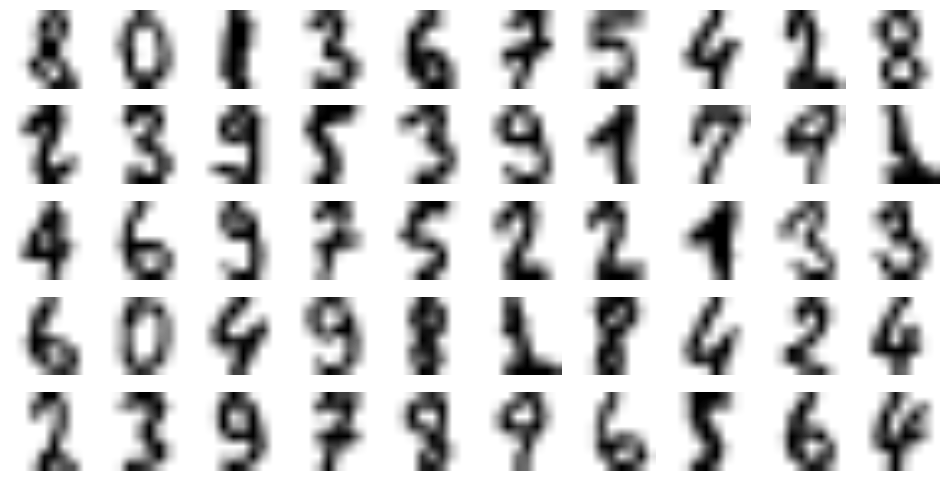

In [73]:
k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train) # 计算每个点到这 50 个质心的距离
representative_digit_idx = np.argmin(X_digits_dist, axis=0) # 寻找每个簇中离质心最近的那个点的索引，压缩行，得到50个结果
X_representative_digits = X_train[representative_digit_idx] # 提取出这 50 个“代表性”样本

'''在找出这50个代表性样本后，我们可以人工对其进行检查并手动标记他们
首要任务是1.获取这50张图像'''
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6)) # 1. 创建一个画布，设置比例
# 2. 循环遍历这 50 个代表性样本
for index, image_data in enumerate(X_representative_digits): # image_data是长度为 64 的一维长条（向量）
    plt.subplot(5, 10, index + 1) # 创建 5行 10列 的子图
    # 核心：将 64 维向量恢复成 8x8 的图像形状
    # cmap="binary" 是为了显示成灰度图
    plt.imshow(image_data.reshape(8, 8), cmap="binary", interpolation="bilinear")
    plt.axis("off") # 隐藏坐标轴，让画面更整洁
plt.show()
'''1.cmap="binary"（色彩映射）含义：cmap 代表 Colormap（颜色表）。
binary 意思是“二进制”或“黑白”。效果：它会将数值小的像素（接近0）显示为白色，数值大的像素显示为黑色。
如果不加：Matplotlib 默认会用一种紫黄色的彩色滤镜（Viridis），看起来会像热力图，不像原始的手写数字。

2. interpolation="bilinear"（双线性插值）含义：这是一种平滑处理技术。
为什么要用？ 我们的数字图分辨率极低，只有8x8。直接画出来会有非常强烈的“马赛克”感（大方块）。
效果：bilinear 会在像素点之间进行模糊过渡，让锯齿状的边缘变得平滑、圆润。
提示：如果想看最原始、最硬的像素方块，可以把这个参数改成 "nearest"。'''
# 2. 手动标注的 50 个代表性样本标签
y_representative_digits = np.array([
    8, 0, 1, 3, 6, 7, 5, 4, 2, 8,
    2, 3, 9, 5, 3, 9, 1, 7, 9, 1,
    4, 6, 9, 7, 5, 2, 2, 1, 3, 3,
    6, 0, 4, 9, 8, 1, 8, 4, 2, 4,
    2, 3, 9, 7, 8, 9, 6, 5, 6, 4
])

### 我们需要解释一下fit()与fit_transform()的区别

简单来说：`fit()` 的目的是“分类”**，而 `fit_transform()` 在这里的目的是**“量化”。

#### 1. 如果只用 `fit()`

当你执行 `kmeans.fit(X_train)` 时，你告诉模型：“去把这 1400 张图分成 50 堆。”

* **模型内部发生了什么？** 它计算出了 50 个质心的位置。
* **你能得到什么？** 你能得到每个点属于哪个堆（`labels_`）。（这里的标签不是真实标签，而是分组编号）
* **缺失了什么？** 它**没有告诉你**每一个点距离它的“堆中心”到底有多远。

如果你只有 `fit()`，你只知道哪些点是 1 号堆的，但你无法判断谁是 1 号堆里长得最标准（最靠近中心）的那张图。

#### 2. 使用 `fit_transform()`

当你执行 `X_digits_dist = kmeans.fit_transform(X_train)` 时，模型在完成分类的同时，还吐出了一个非常关键的**距离矩阵**。

假设我们有 1400 张图，聚成 50 类。这个 `X_digits_dist` 的形状就是 **(1400, 50)**。

* **每一行**代表一张图片。
* **每一列**代表到一个质心的距离。


### 总结对比

| 方法 | 返回值 | 你的真实目的 |
| --- | --- | --- |
| **`fit(X)`** | 模型本身 | 仅仅是为了让模型学会怎么分组。 |
| **`fit_transform(X)`** | **每个点到每个质心的具体距离** | 为了利用这些距离，**精准定位**出每组中最典型的那个样本。 |


#### 我们利用新获取到的这50个具有代表性的数据，重新对分类模型进行训练

In [74]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits,y_representative_digits)
log_reg.score(X_test,y_test)
# 我们可以看到，模型的精度得到了显著的提升

0.8312342569269522

#### 进一步地，现在我们可以利用这些代表性样本进行标签扩散

In [75]:
# 1. 先创建一个空的、长度为 1400 的数组，准备用来装标签
y_train_propagated = np.empty(len(X_train), dtype=np.int64)

# 2. 循环 50 次（k=50，对应 50 个簇）
for i in range(k):
    # 找到所有属于第 i 个簇（分组编号）的样本索引，设为该簇代表性样本的标签
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

# 下面来查看其性能
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train,y_train_propagated)
log_reg.score(X_test,y_test)

0.8690176322418136

#### 如果我们还想做得更好，可以忽略里集群中心最远的1%的实例

In [ ]:
percentile_closest = 99 #保留距离集群中心最近的 99% 的数据

# 利用 NumPy 的高级索引获取每个实例到其所属集群中心的距离
X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
'''当你使用 X_digits_dist[rows, cols] 这种语法时，你传入了两个一维的索引数组：
rows：[0, 1, 2, ...] (长度为 N)
cols：[label0, label1, label2, ...] (长度为 N)

NumPy 的处理逻辑是：它不再看整个矩阵，而是把这两组索引看作 (x, y) 坐标对。它会依次取出：
第 1 个点：(rows[0], cols[0]) -> 得到 1 个标量值
第 2 个点：(rows[1], cols[1]) -> 得到 1 个标量值
...
第 N 个点：(rows[N-1], cols[N-1]) -> 得到 1 个标量值
最后，它把这 N 个抽出来的标量值重新打包。因为你只提供了 N 组坐标，结果自然就是一个长度为 N 的一维数组。'''
for i in range(k):
    in_cluster = (kmeans.labels_ == i) # 创建一个布尔掩码（Boolean Mask），找出所有属于第 i 个集群的样本索引
    cluster_dist = X_cluster_dist[in_cluster]
    # 计算当前集群中第99百分位数的距离作为阈值
    cutoff_distance = np.percentile(cluster_dist, percentile_closest) # np.percentile 计算当前集群距离的第 99 分位数。超过这个距离的样本就被认为是离群点。
    above_cutoff = (X_cluster_dist > cutoff_distance) # 再次创建一个布尔掩码，标记出全集中所有距离超过刚刚计算出的 cutoff_distance 的点。
    # 将该集群中超过阈值的实例距离标记为 -1
    X_cluster_dist[in_cluster & above_cutoff] = -1 # ：只有属于当前集群且距离超过阈值的点，其在 X_cluster_dist 中的值才会被改写为 -1

# 过滤掉标记为 -1 的异常值
partially_propagated = (X_cluster_dist != -1) # 保留所有非 -1 的正常数据
X_train_partially_propagated = X_train[partially_propagated] # 利用掩码对特征矩阵 X 和标签向量 y 进行切片
y_train_partially_propagated = y_train_propagated[partially_propagated]

# 下面来查看其性能
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_partially_propagated,y_train_partially_propagated)
log_reg.score(X_test,y_test)

0.8639798488664987

##### 举一个具体例子来展示具体计算过程

### 场景设定

* **样本数量 ($N$):** 4个样本
* **集群数量 ($k$):** 2个集群（0号和1号）
* **剔除比例:** 设为 50%（即 `percentile_closest = 50`），以便我们可以清晰地看到有一半的数据被剔除。

### 1. 初始数据状态

假设我们已经得到了每个样本到两个中心的距离矩阵 `X_digits_dist`：

| 样本索引 | 到中心0距离 | 到中心1距离 | **所属集群 (labels_)** |
| --- | --- | --- | --- |
| **0** | **1.0** | 5.0 | **0** |
| **1** | **4.0** | 6.0 | **0** (离群) |
| **2** | 3.0 | **0.5** | **1** |
| **3** | 7.0 | **2.5** | **1** (离群) |

### 2. 逐行执行计算

#### 第一步：抽取对应距离

`X_cluster_dist = X_digits_dist[np.arange(4), [0, 0, 1, 1]]`

* 样本0取第0列：1.0
* 样本1取第0列：4.0
* 样本2取第1列：0.5
* 样本3取第1列：2.5
* **结果：** `X_cluster_dist = [1.0, 4.0, 0.5, 2.5]`（变为一维数组）

#### 第二步：进入循环 - 处理集群 0 (`i = 0`)

1. `in_cluster = [True, True, False, False]` (只有索引0, 1属于集群0)
2. `cluster_dist = [1.0, 4.0]`
3. **计算中位数 (50%):** `cutoff_distance = 1.0`（在 1.0 和 4.0 之间，取决于具体插值算法，这里简化为 1.0）
4. `above_cutoff = [False, True, False, True]` (全集中谁的距离大于1.0？结果是索引1, 3)
5. **执行标记:** `in_cluster & above_cutoff` 仅对索引 **1** 为 True。
* `X_cluster_dist` 变为 `[1.0, -1, 0.5, 2.5]`

#### 第三步：继续循环 - 处理集群 1 (`i = 1`)

1. `in_cluster = [False, False, True, True]` (只有索引2, 3属于集群1)
2. `cluster_dist = [0.5, 2.5]`
3. **计算中位数 (50%):** `cutoff_distance = 0.5`
4. `above_cutoff = [True, True, False, True]` (全集中谁的距离大于0.5？结果是索引0, 1, 3)
5. **执行标记:** `in_cluster & above_cutoff` 仅对索引 **3** 为 True。
* `X_cluster_dist` 最终变为 `[1.0, -1, 0.5, -1]`

#### 第四步：最终过滤

`partially_propagated = [True, False, True, False]`

* **X_train_partially_propagated:** 仅保留原数据集中的索引 **0** 和 **2**。
* **结果：** 索引 1 和 3 因为在各自的集群中距离太远，被成功剔除。

### 3. 计算过程总结表

| 样本 | 初始距离 | 集群 | 该集群阈值 | 是否 > 阈值 | 最终状态 |
| --- | --- | --- | --- | --- | --- |
| 0 | 1.0 | 0 | 1.0 | 否 | **保留** |
| 1 | 4.0 | 0 | 1.0 | 是 | **剔除 (-1)** |
| 2 | 0.5 | 1 | 0.5 | 否 | **保留** |
| 3 | 2.5 | 1 | 0.5 | 是 | **剔除 (-1)** |

---

#### 准确率反而下降的原因

### 1. 误删了“困难但关键”的样本

在聚类中，处于 99% 分位数之外的样本并不一定是“噪声”，它们可能是**边界样本（Borderline Samples）**。

* **原理：** 某些样本虽然距离聚类中心较远，但它们依然承载了该类别的特征信息。
* **后果：** 剔除这些样本会导致模型失去了学习“类别边缘”的能力。在测试集中，如果出现类似的边缘样本，模型由于在训练阶段没见过这些“长相奇特”的同类，就会发生误判。

### 2. 采样偏差与数据分布不平衡

如果你的数据集本身比较小，或者某些类别的分布非常稀疏，强行剔除 1% 可能会破坏该类别的**统计完整性**。

* **局部代表性不足：** 假设某个小集群只有 100 个点，剔除 1 个点看似不多，但如果这个点刚好是连接两个区域的桥梁，剔除它会导致模型对该区域的覆盖产生“空洞”。

### 3. 标签传播的“修正效应”消失

在你参考的代码上下文中，这些标签往往是自动传播（Propagated）的，而不是人工标注的。

* **情况 A：** 如果这些 1% 的离群点其实被**正确标记**了，剔除它们就减少了有效的训练数据量（Data Quantity Issue）。
* **情况 B：** 机器学习模型（如 SVM 或随机森林）通常具有一定的鲁棒性。即使存在少量离群点，模型也能通过全局优化忽略它们。但如果你剔除了过多的点，导致训练集规模缩小，模型的方差（Variance）可能会增大。

### 4. 离群点判定标准的局限性

代码中使用的是欧氏距离（Euclidean Distance）来判断离群。

* **维度灾难：** 在高维空间（如你处理的多模态数据或手写数字图像）中，欧氏距离的解释力会下降。
* **形状误判：** K-Means 假设集群是球形的。如果实际数据的分布是长条形或不规则形状，距离中心最远的 1% 样本可能正是该类别的核心组成部分，而非异常。

### 建议的排查步骤：

1. **观察被剔除的是什么：** 可视化那些被标记为 `-1` 的样本。如果被剔除的数字依然清晰可辨（比如虽然离中心远，但一眼就能看出是 "5"），说明剔除策略太激进。
2. **调整阈值：** 尝试将 `percentile_closest` 从 `99` 改为 `99.5` 或 `99.9`。
3. **对比实验：** 检查准确率下降是发生在训练集上还是验证集上。如果训练集准确率上升但验证集下降，说明发生了过拟合。

在进行多模态研究时，不同模态的噪声水平不同，统一使用 99% 的硬性阈值可能并不适配所有数据特征，可以尝试针对不同模态设置不同的过滤策略。

## 2. DBSCAN 密度聚类

### 2.1 代码演示

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X,y = make_moons(n_samples=1000, noise=0.05)
dbsacn = DBSCAN(eps=0.05, min_samples=5) # eps是邻域半径，最小样本点是筛选核心对象的阈值
dbsacn.fit(X)
print(X.shape)

print("=============")
# 得到所有实例的标签,若得到的索引为负值，说明其被标记为异常
print(dbsacn.labels_[:100])

print(dbsacn.core_sample_indices_[:50]) # 得到核心对象的索引
print(dbsacn.components_[:50]) # 得到核心实例本身
print("=============")

# 观察形状
print(dbsacn.core_sample_indices_.shape)
print(dbsacn.components_.shape)

(1000, 2)
[ 0  1 -1  2  0  3  4  4  2  1  2  4  4 -1  3  4  2  1  5  6  3  2  7 -1
  6 -1 -1  4  1 -1  5  0 11  0  1  2  1  2  3  4  4 -1 -1  3  4  4  7  1
  5  1  7  2  4  7  4  7  8  4  2 -1  1  6  2  2  2  9  7  5  1  4  4  1
  1  3 -1  7  1  2  5  7 -1 10  1 -1  0 -1  1  0  3  7  0  1  1  4  7  1
  5  1  7  2]
[ 0  1  3  4  5  6  7  8  9 10 12 14 15 16 17 18 19 21 22 24 27 28 30 31
 33 34 35 36 37 38 39 40 43 44 45 46 47 48 50 51 53 54 55 56 57 58 60 61
 62 63]
[[ 0.58607216 -0.44651188]
 [ 0.93905612  0.36898243]
 [ 1.3067895  -0.46315505]
 [ 0.44844443 -0.37363177]
 [ 0.17422179 -0.1473036 ]
 [-0.97198737  0.17411818]
 [-0.96389161  0.29224746]
 [ 1.27449675 -0.48558439]
 [ 0.78457154  0.60153423]
 [ 1.35213506 -0.38500293]
 [-0.88407965  0.44611164]
 [ 0.12240396  0.01771925]
 [-0.97323542  0.3551559 ]
 [ 1.07011903 -0.47909691]
 [ 0.26061627  0.97203509]
 [ 0.98294373  0.11138639]
 [ 1.8506879  -0.16239439]
 [ 1.30870648 -0.42282855]
 [-0.51863419  0.86117875]
 [ 1.75752908 -0.

### 2.2 二次建模

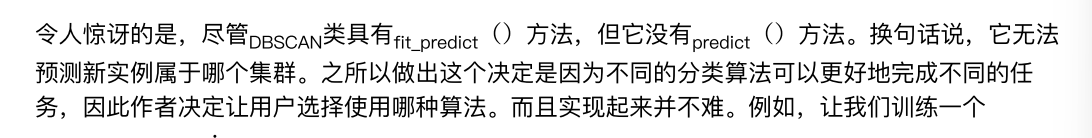

### 1. 两个具体方法的作用

在 Scikit-Learn 的 API 设计中，这两个方法有着明确的分工：

* **`fit_predict()`**：
    * **作用**：它相当于“一气呵成”。算法会对传入的训练数据进行学习（fit），并在**学习的过程中**直接给这组数据打上集群标签（predict）。
    * **特点**：它返回的是这组数据自身的聚类结果。对于 DBSCAN 这种基于密度的算法，它在扫描密度的同时就能确定每个点属于哪个“团块”。

* **`predict()`**：
    * **作用**：它用于“预测未来”。假设模型已经训练好了，现在来了一个**全新的、之前没见过**的样本点，`predict()` 会根据已有的模型规则（比如 K-Means 的中心点坐标）告诉我们这个新点属于哪个类。

### 2. 为什么 DBSCAN 无法对新实例做出预测？

这是由 **DBSCAN 的算法本质**决定的。

* **K-Means 为什么能预测？** 因为 K-Means 训练完后会留下 $k$ 个固定的“中心点坐标”。新来一个点，只需要计算它离哪个中心近就行了。这是一种基于质心（Centroid-based）的逻辑。
* **DBSCAN 为什么不能？** DBSCAN 是基于密度连接（Density-based）的。它认为一个集群是“一堆密度相连的核心点”。
* 如果要预测一个新点，算法必须重新扫描该点周围的密度，甚至可能因为这个新点的加入，导致原本分离的两个集群连接在一起，或者产生连锁反应。
* **代价太大**：为了预测一个点，可能需要重新计算局部的密度分布，这违背了普通 `predict()` 方法追求的高效、静态预测的初衷。

### 3. 如何理解“让用户决定使用哪种算法”？

这句话的意思是：既然 DBSCAN 本身不提供针对新数据的 `predict()` 功能，开发者建议你“组合建模”。你可以把 DBSCAN 当作一个优秀的“自动标签器”，然后再用一个专业的分类器去学习它的结果。

**具体操作流程通常是这样的：**

1. **聚类打标**：对现有数据运行 DBSCAN，得到一堆标签（比如 0, 1, 2, -1）。
2. **数据清洗**：剔除噪声（标签为 -1 的点）。
3. **二次建模（用户决定的部分）**：
    * 如果你喜欢速度快，你可以训练一个 **KNN** 分类器去拟合这些标签。
    * 如果你追求泛化能力，你可以训练一个 **SVM** 或 **随机森林**。

4. **最终预测**：当新实例到来时，你不调用 DBSCAN，而是调用你后来训练的那个分类器（如 KNN）的 `predict()`。

**这样做的好处：**

* **灵活性**：你可以根据数据量和精度要求，自由选择最适合的分类算法。
* **解决边界问题**：DBSCAN 很难处理新点在边缘的情况，但分类器（如 SVM）能通过超平面给出更明确的归属判断。

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
knn = KNeighborsClassifier(n_neighbors=50)
# fit(特征数据, 目标标签),使用处于密度中心、最具代表性的样本，构建了一个最纯净、最稳健的骨架
# 当然实际上，我们也可以选择所有实例或除异常值之外的所有样本之外进行训练
knn.fit(dbsacn.components_,dbsacn.labels_[dbsacn.core_sample_indices_]) # dbsacn.labels_是分组编号

# 给出实例进行预测
X_new = np.array([[-0.5,0],[0,0.5],[1,-0.1],[2,1]])
print(knn.predict(X_new))
print(knn.predict_proba(X_new))

[4 3 5 8]
[[0.   0.   0.   0.24 0.76 0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.  ]
 [0.   0.02 0.   0.82 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.16]
 [0.02 0.   0.3  0.   0.   0.44 0.   0.   0.   0.   0.   0.24 0.   0.
  0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.68 0.   0.   0.   0.32 0.
  0.  ]]


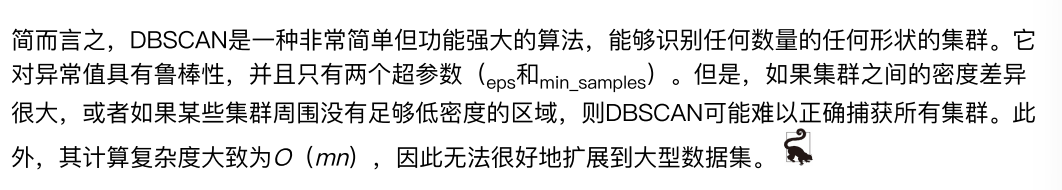

## 3. 高斯混合模型

> 自行见书